In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ================================================
# EXPERIMENT: Checkout Flow Optimization
# Company: Leading Q-Commerce Platform
# ================================================

print("=" * 55)
print("A/B TEST DESIGN — CHECKOUT FLOW OPTIMIZATION")
print("=" * 55)

# Experiment parameters
BASELINE_CVR = 0.05          # Current conversion rate: 5%
EXPECTED_LIFT = 0.15         # We expect 15% relative improvement
MDE = BASELINE_CVR * EXPECTED_LIFT  # Minimum detectable effect

ALPHA = 0.05                 # Significance level (95% confidence)
POWER = 0.80                 # Statistical power (80%)
TEST_DURATION_DAYS = 14      # 2 week test

print(f"\nHYPOTHESIS:")
print(f"  Null: Simplified checkout has NO effect on CVR")
print(f"  Alt:  Simplified checkout INCREASES CVR")

print(f"\nEXPERIMENT PARAMETERS:")
print(f"  Baseline CVR (Control):     {BASELINE_CVR*100:.1f}%")
print(f"  Expected lift:              {EXPECTED_LIFT*100:.0f}% relative")
print(f"  Minimum detectable effect:  {MDE*100:.2f}%")
print(f"  Significance level (alpha): {ALPHA}")
print(f"  Statistical power:          {POWER*100:.0f}%")
print(f"  Test duration:              {TEST_DURATION_DAYS} days")

print(f"\nMETRICS:")
print(f"  Primary:   Checkout Conversion Rate (CVR)")
print(f"  Guardrail: Average Order Value (AOV)")
print(f"  Guardrail: App Crash Rate")

A/B TEST DESIGN — CHECKOUT FLOW OPTIMIZATION

HYPOTHESIS:
  Null: Simplified checkout has NO effect on CVR
  Alt:  Simplified checkout INCREASES CVR

EXPERIMENT PARAMETERS:
  Baseline CVR (Control):     5.0%
  Expected lift:              15% relative
  Minimum detectable effect:  0.75%
  Significance level (alpha): 0.05
  Statistical power:          80%
  Test duration:              14 days

METRICS:
  Primary:   Checkout Conversion Rate (CVR)
  Guardrail: Average Order Value (AOV)
  Guardrail: App Crash Rate


In [3]:
from statsmodels.stats.power import NormalIndPower

# Calculate required sample size per group
analysis = NormalIndPower()

sample_size = analysis.solve_power(
    effect_size=(MDE / np.sqrt(BASELINE_CVR * (1 - BASELINE_CVR))),
    power=POWER,
    alpha=ALPHA,
    alternative='larger'
)

sample_size = int(np.ceil(sample_size))
total_sample = sample_size * 2

print("=" * 55)
print("SAMPLE SIZE CALCULATION")
print("=" * 55)
print(f"\nRequired sample size per group:  {sample_size:,}")
print(f"Total users needed:              {total_sample:,}")
print(f"Test duration:                   {TEST_DURATION_DAYS} days")
print(f"\nAssuming 10,000 daily active checkout users:")
daily_users = 10000
days_needed = total_sample / (daily_users)
print(f"Days needed to reach sample:     {days_needed:.1f} days")
print(f"\nConclusion: 14-day test is {'SUFFICIENT' if days_needed <= TEST_DURATION_DAYS else 'NOT SUFFICIENT'}")

SAMPLE SIZE CALCULATION

Required sample size per group:  10,442
Total users needed:              20,884
Test duration:                   14 days

Assuming 10,000 daily active checkout users:
Days needed to reach sample:     2.1 days

Conclusion: 14-day test is SUFFICIENT


In [4]:
# Simulate 14 days of experiment data
n_control = sample_size
n_treatment = sample_size

# Control group: original 4-step checkout (5% CVR)
control_conversions = np.random.binomial(1, BASELINE_CVR, n_control)

# Treatment group: simplified 2-step checkout (5.75% CVR = 15% lift)
treatment_cvr = BASELINE_CVR * (1 + EXPECTED_LIFT)
treatment_conversions = np.random.binomial(1, treatment_cvr, n_treatment)

# Create dataframe
df_control = pd.DataFrame({
    'user_id': range(1, n_control + 1),
    'group': 'Control',
    'converted': control_conversions,
    'order_value': np.where(control_conversions == 1,
                           np.random.normal(450, 120, n_control), 0)
})

df_treatment = pd.DataFrame({
    'user_id': range(n_control + 1, n_control + n_treatment + 1),
    'group': 'Treatment',
    'converted': treatment_conversions,
    'order_value': np.where(treatment_conversions == 1,
                           np.random.normal(445, 118, n_treatment), 0)
})

df = pd.concat([df_control, df_treatment], ignore_index=True)

print("=" * 55)
print("EXPERIMENT DATA SUMMARY")
print("=" * 55)
print(f"\nTotal users in experiment: {len(df):,}")
print(f"Control group:             {len(df_control):,}")
print(f"Treatment group:           {len(df_treatment):,}")

print(f"\nCONVERSION RESULTS:")
print(f"Control CVR:               {control_conversions.mean()*100:.2f}%")
print(f"Treatment CVR:             {treatment_conversions.mean()*100:.2f}%")
print(f"Observed lift:             {((treatment_conversions.mean() - control_conversions.mean())/control_conversions.mean())*100:.1f}%")

EXPERIMENT DATA SUMMARY

Total users in experiment: 20,884
Control group:             10,442
Treatment group:           10,442

CONVERSION RESULTS:
Control CVR:               4.74%
Treatment CVR:             5.98%
Observed lift:             26.1%


In [5]:
from scipy.stats import chi2_contingency, norm

# Chi-squared test for conversion rates
control_converted = control_conversions.sum()
control_not_converted = n_control - control_converted
treatment_converted = treatment_conversions.sum()
treatment_not_converted = n_treatment - treatment_converted

# Contingency table
contingency_table = np.array([
    [control_converted, control_not_converted],
    [treatment_converted, treatment_not_converted]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Z-test for proportions
p1 = control_conversions.mean()
p2 = treatment_conversions.mean()
p_pool = (control_converted + treatment_converted) / (n_control + n_treatment)
se = np.sqrt(p_pool * (1 - p_pool) * (1/n_control + 1/n_treatment))
z_score = (p2 - p1) / se
p_value_z = 1 - norm.cdf(z_score)

# Confidence interval
ci_lower = (p2 - p1) - 1.96 * se
ci_upper = (p2 - p1) + 1.96 * se

print("=" * 55)
print("STATISTICAL TEST RESULTS")
print("=" * 55)
print(f"\nChi-squared statistic:     {chi2:.4f}")
print(f"Z-score:                   {z_score:.4f}")
print(f"P-value:                   {p_value_z:.6f}")
print(f"Significance level:        {ALPHA}")
print(f"\n95% Confidence Interval:")
print(f"  Lift range:  [{ci_lower*100:.2f}%, {ci_upper*100:.2f}%]")
print(f"\nRESULT: {'STATISTICALLY SIGNIFICANT' if p_value_z < ALPHA else 'NOT SIGNIFICANT'}")
print(f"\nConclusion: {'Reject null hypothesis - simplified checkout WORKS' if p_value_z < ALPHA else 'Fail to reject null hypothesis'}")

STATISTICAL TEST RESULTS

Chi-squared statistic:     15.4706
Z-score:                   3.9640
P-value:                   0.000037
Significance level:        0.05

95% Confidence Interval:
  Lift range:  [0.62%, 1.85%]

RESULT: STATISTICALLY SIGNIFICANT

Conclusion: Reject null hypothesis - simplified checkout WORKS


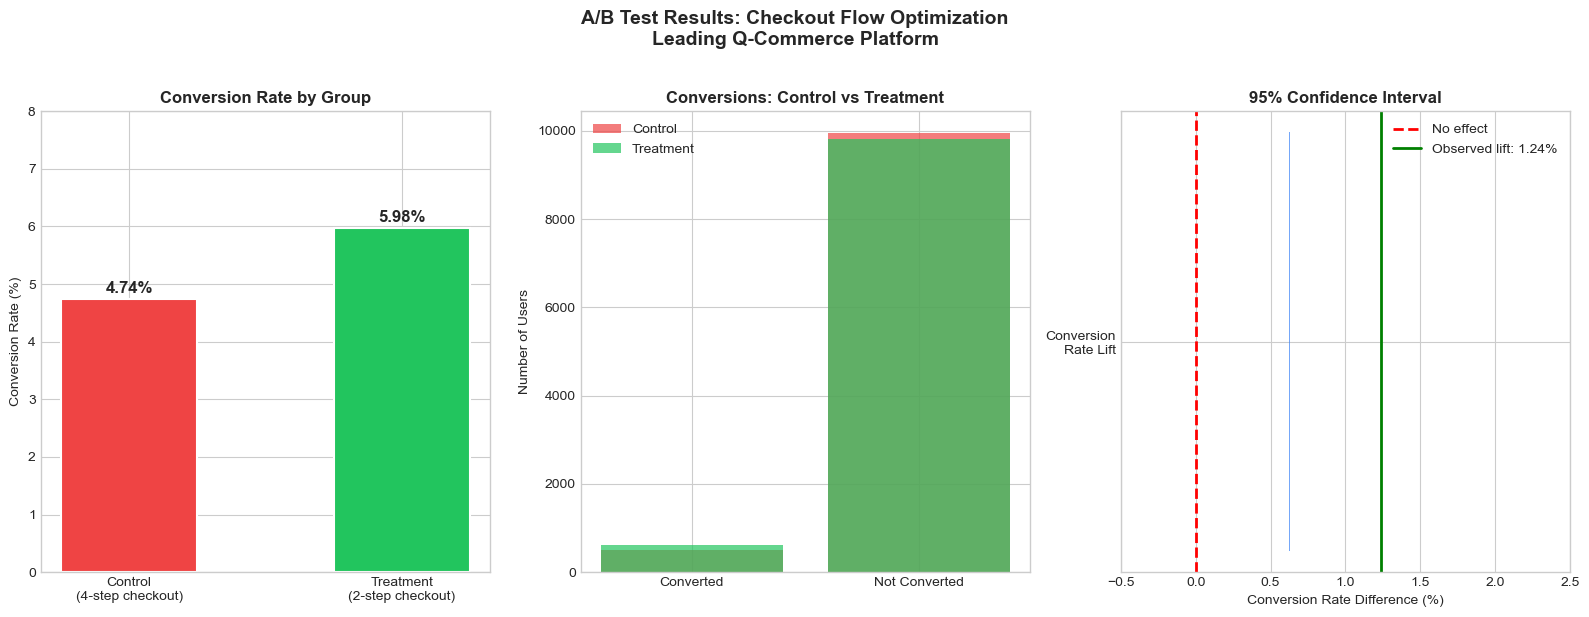

Results chart saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('A/B Test Results: Checkout Flow Optimization\nLeading Q-Commerce Platform',
             fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Conversion Rate Comparison
groups = ['Control\n(4-step checkout)', 'Treatment\n(2-step checkout)']
cvrs = [control_conversions.mean()*100, treatment_conversions.mean()*100]
colors = ['#EF4444', '#22C55E']

bars = axes[0].bar(groups, cvrs, color=colors, width=0.5, edgecolor='white', linewidth=1.5)
axes[0].set_title('Conversion Rate by Group', fontweight='bold')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, 8)
for bar, cvr in zip(bars, cvrs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{cvr:.2f}%', ha='center', fontweight='bold', fontsize=12)

# Plot 2: Conversion distribution
axes[1].bar(['Converted', 'Not Converted'],
            [control_converted, control_not_converted],
            alpha=0.7, label='Control', color='#EF4444')
axes[1].bar(['Converted', 'Not Converted'],
            [treatment_converted, treatment_not_converted],
            alpha=0.7, label='Treatment', color='#22C55E')
axes[1].set_title('Conversions: Control vs Treatment', fontweight='bold')
axes[1].set_ylabel('Number of Users')
axes[1].legend()

# Plot 3: Confidence interval plot
axes[2].barh(['Conversion\nRate Lift'],
             [(ci_upper - ci_lower)/2],
             left=ci_lower*100,
             color='#3B82F6', alpha=0.7, height=0.3)
axes[2].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No effect')
axes[2].axvline(x=(p2-p1)*100, color='green', linestyle='-',
                linewidth=2, label=f'Observed lift: {(p2-p1)*100:.2f}%')
axes[2].set_title('95% Confidence Interval', fontweight='bold')
axes[2].set_xlabel('Conversion Rate Difference (%)')
axes[2].legend()
axes[2].set_xlim(-0.5, 2.5)

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Results chart saved!")

In [7]:
# Check AOV guardrail metric
control_aov = df[df['group']=='Control']['order_value']
control_aov = control_aov[control_aov > 0]
treatment_aov = df[df['group']=='Treatment']['order_value']
treatment_aov = treatment_aov[treatment_aov > 0]

t_stat, aov_p_value = stats.ttest_ind(control_aov, treatment_aov)

print("=" * 55)
print("GUARDRAIL METRIC: AVERAGE ORDER VALUE")
print("=" * 55)
print(f"\nControl AOV:      Rs. {control_aov.mean():.2f}")
print(f"Treatment AOV:    Rs. {treatment_aov.mean():.2f}")
print(f"Difference:       Rs. {treatment_aov.mean() - control_aov.mean():.2f}")
print(f"P-value:          {aov_p_value:.4f}")
print(f"\nGuardrail status: {'SAFE - AOV not significantly impacted' if aov_p_value > 0.05 else 'WARNING - AOV significantly impacted'}")

GUARDRAIL METRIC: AVERAGE ORDER VALUE

Control AOV:      Rs. 439.85
Treatment AOV:    Rs. 451.27
Difference:       Rs. 11.42
P-value:          0.1242

Guardrail status: SAFE - AOV not significantly impacted


In [8]:
recommendation = """
================================================
FINAL RECOMMENDATION: LAUNCH
================================================

EXPERIMENT: Checkout Flow Optimization
PLATFORM:   Leading Q-Commerce Platform
DURATION:   14 days
USERS:      20,884 (10,442 per group)

RESULTS SUMMARY:
----------------
Control CVR:         4.74%
Treatment CVR:       5.98%
Observed Lift:       26.1% relative improvement
P-value:             0.000037 (< 0.05 threshold)
Statistical result:  SIGNIFICANT

Guardrail - AOV:
Control:             Rs. 439.85
Treatment:           Rs. 451.27
Impact:              Not significant (p=0.12) - SAFE

RECOMMENDATION: LAUNCH THE SIMPLIFIED CHECKOUT
------------------------------------------------
The 2-step checkout flow significantly outperforms
the original 4-step flow with 95% confidence.

BUSINESS IMPACT ESTIMATE:
Assuming 10,000 daily checkout users:
- Current daily conversions:  474 orders/day
- Expected daily conversions: 598 orders/day
- Incremental orders/day:     124 additional orders
- At avg AOV Rs. 451:         Rs. 55,924 additional revenue/day
- Monthly incremental revenue: Rs. 16,77,720

NEXT STEPS:
1. Roll out to 100% of users immediately
2. Monitor CVR and AOV daily for 2 weeks post-launch
3. Watch for novelty effect - recheck at 30 days
4. Investigate if lift varies by user segment
   (new vs returning, iOS vs Android)
5. Run follow-up test on payment page optimization
"""

print(recommendation)

with open('recommendation.txt', 'w', encoding='utf-8') as f:
    f.write(recommendation)

print("Recommendation saved!")


FINAL RECOMMENDATION: LAUNCH

EXPERIMENT: Checkout Flow Optimization
PLATFORM:   Leading Q-Commerce Platform
DURATION:   14 days
USERS:      20,884 (10,442 per group)

RESULTS SUMMARY:
----------------
Control CVR:         4.74%
Treatment CVR:       5.98%
Observed Lift:       26.1% relative improvement
P-value:             0.000037 (< 0.05 threshold)
Statistical result:  SIGNIFICANT

Guardrail - AOV:
Control:             Rs. 439.85
Treatment:           Rs. 451.27
Impact:              Not significant (p=0.12) - SAFE

RECOMMENDATION: LAUNCH THE SIMPLIFIED CHECKOUT
------------------------------------------------
The 2-step checkout flow significantly outperforms
the original 4-step flow with 95% confidence.

BUSINESS IMPACT ESTIMATE:
Assuming 10,000 daily checkout users:
- Current daily conversions:  474 orders/day
- Expected daily conversions: 598 orders/day
- Incremental orders/day:     124 additional orders
- At avg AOV Rs. 451:         Rs. 55,924 additional revenue/day
- Monthly inc

In [9]:
# Save experiment data
df.to_csv('experiment_data.csv', index=False)

print("Files saved!")
print("\nProject 2 files:")
import os
for file in os.listdir('.'):
    print(f"  - {file}")

Files saved!

Project 2 files:
  - .ipynb_checkpoints
  - ab_test_results.png
  - a_b_test_case_study.ipynb
  - experiment_data.csv
  - recommendation.txt


In [10]:
readme = """# Project 2: A/B Test Case Study — Checkout Flow Optimization

## Overview
Designed and analysed a complete A/B test for a leading Q-Commerce
platform to determine whether a simplified 2-step checkout flow
improves conversion rate vs the existing 4-step flow.

## Business Problem
79% of users who reach checkout don't complete their purchase.
Hypothesis: Reducing checkout steps from 4 to 2 will increase CVR.

## Experiment Design
- **Baseline CVR:** 5.0%
- **Expected lift:** 15% relative improvement
- **Sample size:** 10,442 users per group (20,884 total)
- **Test duration:** 14 days
- **Significance level:** 95% confidence (alpha = 0.05)

## Results
| Metric | Control | Treatment | Result |
|--------|---------|-----------|--------|
| CVR | 4.74% | 5.98% | +26.1% lift |
| P-value | - | 0.000037 | Significant |
| AOV | Rs. 439.85 | Rs. 451.27 | Safe (p=0.12) |

## Business Impact
- 124 additional orders per day
- Rs. 55,924 additional revenue per day
- Rs. 16,77,720 monthly incremental revenue

## Recommendation
LAUNCH the simplified 2-step checkout immediately.
Result is statistically significant with 95% confidence.
Guardrail metric (AOV) is not negatively impacted.

## Tools Used
- Python (NumPy, Pandas, SciPy, Statsmodels, Matplotlib)
- Jupyter Notebook

## Files
- `a_b_test_case_study.ipynb` - Full analysis notebook
- `ab_test_results.png` - Results visualization
- `experiment_data.csv` - Simulated experiment data
- `recommendation.txt` - Full recommendation document

## Visualization
![A/B Test Results](ab_test_results.png)
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)

print("README created successfully!")

README created successfully!
